# Clustering y Reducción de Dimensionalidad en un Portafolio de Inversiones

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

from scipy.optimize import minimize
import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore")

In [11]:
tickers = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "META",
    "NVDA", "TSLA", "AVGO", "ORCL", "CRM",
    "JPM", "BAC", "GS", "MS", "WFC",
    "V", "MA", "AXP", "BLK", "C",
    "JNJ", "PFE", "MRK", "ABBV", "LLY",
    "UNH", "TMO", "ABT", "MDT", "BMY",
    "XOM", "CVX", "COP", "SLB", "EOG",
    "WMT", "COST", "HD", "MCD", "NKE",
    "KO", "PEP", "PG", "CL", "KMB",
    "CAT", "BA", "GE", "UPS", "HON"
]

In [12]:
precios = yf.download(
    tickers,
    period="5y",
    interval="1d",
    auto_adjust=True,
    progress=False
)["Close"]

precios.head()

Ticker,AAPL,ABBV,ABT,AMZN,AVGO,AXP,BA,BAC,BLK,BMY,...,PG,SLB,TMO,TSLA,UNH,UPS,V,WFC,WMT,XOM
2021-08-16,147.398071,98.557426,113.108032,164.949493,44.439423,155.976120,229.059998,36.531815,819.872864,55.961620,...,127.204292,24.893658,546.759949,228.723328,382.166992,157.222198,226.610489,43.744160,47.316521,47.250343
2021-08-17,146.490982,99.597816,114.042587,162.098007,43.579113,154.940994,222.220001,36.354870,806.336792,56.189758,...,127.415344,24.364960,548.584290,221.903336,386.353180,157.772690,225.811386,43.124428,47.300819,46.929379
2021-08-18,142.755310,97.625198,112.445671,160.061005,42.694225,152.569580,219.000000,36.089439,799.502075,55.350502,...,126.025810,24.024437,537.095886,229.663330,382.267822,155.411179,223.019165,42.469276,46.798622,45.941124
2021-08-19,143.086960,98.157890,114.069817,159.387497,43.109348,149.652420,212.160004,35.558567,801.159973,55.823109,...,127.512100,23.692881,544.215881,224.490005,391.950012,154.820831,222.961380,41.831837,47.115623,44.538994
2021-08-20,144.540237,98.898659,114.614212,159.997498,43.258652,150.329941,212.669998,35.717838,813.029602,56.385319,...,127.600060,23.710810,547.292419,226.753326,393.617157,154.981216,222.759201,41.982346,47.536228,44.547440


## Retornos

In [15]:
retornos = precios.pct_change().dropna()

print("Dimensiones:", retornos.shape)
retornos.head()

Dimensiones: (1248, 50)


Ticker,AAPL,ABBV,ABT,AMZN,AVGO,AXP,BA,BAC,BLK,BMY,...,PG,SLB,TMO,TSLA,UNH,UPS,V,WFC,WMT,XOM
2021-08-17,-0.006154,0.010556,0.008262,-0.017287,-0.019359,-0.006636,-0.029861,-0.004844,-0.016510,0.004077,...,0.001659,-0.021238,0.003337,-0.029818,0.010954,0.003501,-0.003526,-0.014167,-0.000332,-0.006793
2021-08-18,-0.025501,-0.019806,-0.014003,-0.012566,-0.020305,-0.015305,-0.014490,-0.007301,-0.008476,-0.014936,...,-0.010906,-0.013976,-0.020942,0.034970,-0.010574,-0.014968,-0.012365,-0.015192,-0.010617,-0.021058
2021-08-19,0.002323,0.005457,0.014444,-0.004208,0.009723,-0.019120,-0.031233,-0.014710,0.002074,0.008538,...,0.011794,-0.013801,0.013256,-0.022526,0.025328,-0.003799,-0.000259,-0.015009,0.006774,-0.030520
2021-08-20,0.010157,0.007547,0.004772,0.003827,0.003463,0.004527,0.002404,0.004479,0.014816,0.010071,...,0.000690,0.000757,0.005653,0.010082,0.004253,0.001036,-0.000907,0.003598,0.008927,0.000190
2021-08-23,0.010257,0.004545,-0.003800,0.020600,0.015321,0.004382,0.031645,0.013376,0.011655,-0.003757,...,-0.005100,0.038927,-0.004306,0.038280,-0.010123,-0.001242,0.012016,0.004007,-0.006603,0.041145


## Resumen estadístico

In [16]:
def resumen_estadistico(retornos):
    
    resumen = pd.DataFrame({
        "Media": retornos.mean(),
        "Mediana": retornos.median(),
        "Desv_Estandar": retornos.std(),
        "Asimetria": retornos.skew(),
        "Kurtosis": retornos.kurtosis()
    })
    
    return resumen

resumen = resumen_estadistico(retornos)

resumen.head(10)

,Media,Mediana,Desv_Estandar,Asimetria,Kurtosis
Ticker,,,,,
AAPL,0.000825,0.001137,0.017572,0.435779,6.642394
ABBV,0.000887,0.000988,0.014776,-0.872124,7.283931
ABT,0.000087,0.000182,0.014456,-0.046752,6.401581
AMZN,0.000537,0.000330,0.022488,0.155874,4.723020
AVGO,0.002140,0.000807,0.027810,0.726438,8.989982
AXP,0.000815,0.000711,0.018619,0.108026,5.414697
BA,0.000227,0.000023,0.023055,0.062243,3.628687
BAC,0.000571,0.000435,0.016797,-0.042486,3.518827
BLK,0.000430,0.000371,0.017010,0.381667,5.624167


In [17]:
mercado = yf.download(
    "^GSPC",
    period="5y",
    interval="1d",
    auto_adjust=True,
    progress=False
)["Close"]

ret_mercado = mercado.pct_change().dropna()

ret_mercado.head()

Ticker,^GSPC
2021-08-17,-0.007061
2021-08-18,-0.010748
2021-08-19,0.001257
2021-08-20,0.008142
2021-08-23,0.008524


In [18]:
def calcular_betas(retornos, ret_mercado):
    
    betas = {}
    
    for ticker in retornos.columns:
        
        datos = pd.concat(
            [retornos[ticker], ret_mercado],
            axis=1
        ).dropna()
        
        datos.columns = ["activo", "mercado"]
        
        beta = datos["activo"].cov(datos["mercado"]) / datos["mercado"].var()
        
        betas[ticker] = beta
    
    return pd.Series(betas, name="Beta")


betas = calcular_betas(retornos, ret_mercado)

betas.sort_values()

JNJ      0.166099
KMB      0.208802
CL       0.214633
KO       0.265002
MRK      0.277007
BMY      0.280293
PEP      0.283782
PG       0.289444
ABBV     0.307093
MCD      0.366637
PFE      0.400397
WMT      0.411263
XOM      0.412608
UNH      0.420618
CVX      0.477046
ABT      0.507034
MDT      0.532375
EOG      0.572642
LLY      0.582517
COP      0.608443
COST     0.700401
HON      0.788743
V        0.811936
SLB      0.835754
HD       0.837610
UPS      0.850083
TMO      0.863889
JPM      0.888815
MA       0.892778
BAC      0.965102
WFC      0.982757
CAT      1.065951
NKE      1.069562
GE       1.088319
C        1.105016
MSFT     1.142843
BA       1.149463
GS       1.157592
AXP      1.174580
MS       1.176511
BLK      1.189991
AAPL     1.199216
ORCL     1.212670
CRM      1.238613
GOOGL    1.257016
AMZN     1.498700
META     1.603866
AVGO     1.667250
TSLA     2.038589
NVDA     2.172954
Name: Beta, dtype: float64

In [19]:
def clasificar_beta(beta):
    if beta < 0.8:
        return "Baja"
    elif beta <= 1.2:
        return "Media"
    else:
        return "Alta"


resumen["Beta"] = betas
resumen["Nivel_Beta"] = resumen["Beta"].apply(clasificar_beta)

resumen.sort_values("Beta")

,Media,Mediana,Desv_Estandar,Asimetria,Kurtosis,Beta,Nivel_Beta
Ticker,,,,,,,
JNJ,0.000455,0.000308,0.011005,0.131100,4.356402,0.166099,Baja
KMB,0.000088,0.000385,0.013090,-1.071826,14.671211,0.208802,Baja
CL,0.000321,0.000424,0.011981,-0.217469,1.869845,0.214633,Baja
KO,0.000534,0.000639,0.010491,-0.050956,3.568364,0.265002,Baja
MRK,0.000659,0.000611,0.015210,-0.241152,5.993042,0.277007,Baja
BMY,0.000210,-0.000180,0.015483,0.411245,5.904792,0.280293,Baja
PEP,0.000110,0.000092,0.011893,0.018847,3.092636,0.283782,Baja
PG,0.000172,0.000643,0.011417,-0.362397,2.567785,0.289444,Baja
ABBV,0.000887,0.000988,0.014776,-0.872124,7.283931,0.307093,Baja


In [20]:
resumen["Nivel_Beta"].value_counts()

Nivel_Beta
Baja     22
Media    20
Alta      8
Name: count, dtype: int64

# Matriz de correlaciones

In [87]:
matriz_corr = retornos.corr()

matriz_corr

Ticker,AAPL,ABBV,ABT,AMZN,AVGO,AXP,BA,BAC,BLK,BMY,...,PG,SLB,TMO,TSLA,UNH,UPS,V,WFC,WMT,XOM
Ticker,,,,,,,,,,,,,,,,,,,,,
AAPL,1.000000,0.131553,0.278638,0.532199,0.421054,0.450733,0.386486,0.385242,0.537721,0.127413,...,0.253434,0.230592,0.355989,0.470974,0.105619,0.381678,0.469102,0.348511,0.261927,0.172088
ABBV,0.131553,1.000000,0.320940,0.032299,0.017698,0.168007,0.089655,0.193809,0.177211,0.401468,...,0.335929,0.117937,0.305650,-0.002046,0.186559,0.212933,0.255673,0.180218,0.214240,0.160525
ABT,0.278638,0.320940,1.000000,0.191605,0.063766,0.256608,0.187423,0.280864,0.348865,0.268631,...,0.386989,0.090722,0.427343,0.077418,0.173006,0.282614,0.383783,0.240419,0.225186,0.102580
AMZN,0.532199,0.032299,0.191605,1.000000,0.442681,0.456203,0.383359,0.374336,0.500216,0.041015,...,0.094565,0.178217,0.346782,0.444315,0.088005,0.333319,0.389918,0.337922,0.204911,0.088146
AVGO,0.421054,0.017698,0.063766,0.442681,1.000000,0.355111,0.310960,0.262174,0.401424,-0.044712,...,-0.015052,0.180130,0.250378,0.417429,0.029065,0.211304,0.257984,0.251941,0.097095,0.057948
AXP,0.450733,0.168007,0.256608,0.456203,0.355111,1.000000,0.458728,0.683028,0.620419,0.168920,...,0.166190,0.335022,0.401855,0.400399,0.180624,0.393231,0.576688,0.652789,0.191219,0.249823
BA,0.386486,0.089655,0.187423,0.383359,0.310960,0.458728,1.000000,0.405313,0.442569,0.066852,...,0.112624,0.272954,0.233820,0.343191,0.108757,0.289593,0.317370,0.392215,0.180007,0.165940
BAC,0.385242,0.193809,0.280864,0.374336,0.262174,0.683028,0.405313,1.000000,0.635257,0.187011,...,0.174404,0.377518,0.352152,0.332449,0.160171,0.416144,0.458188,0.818141,0.198197,0.307763
BLK,0.537721,0.177211,0.348865,0.500216,0.401424,0.620419,0.442569,0.635257,1.000000,0.187968,...,0.258979,0.329387,0.448086,0.389229,0.184432,0.436970,0.506473,0.569495,0.236092,0.215919


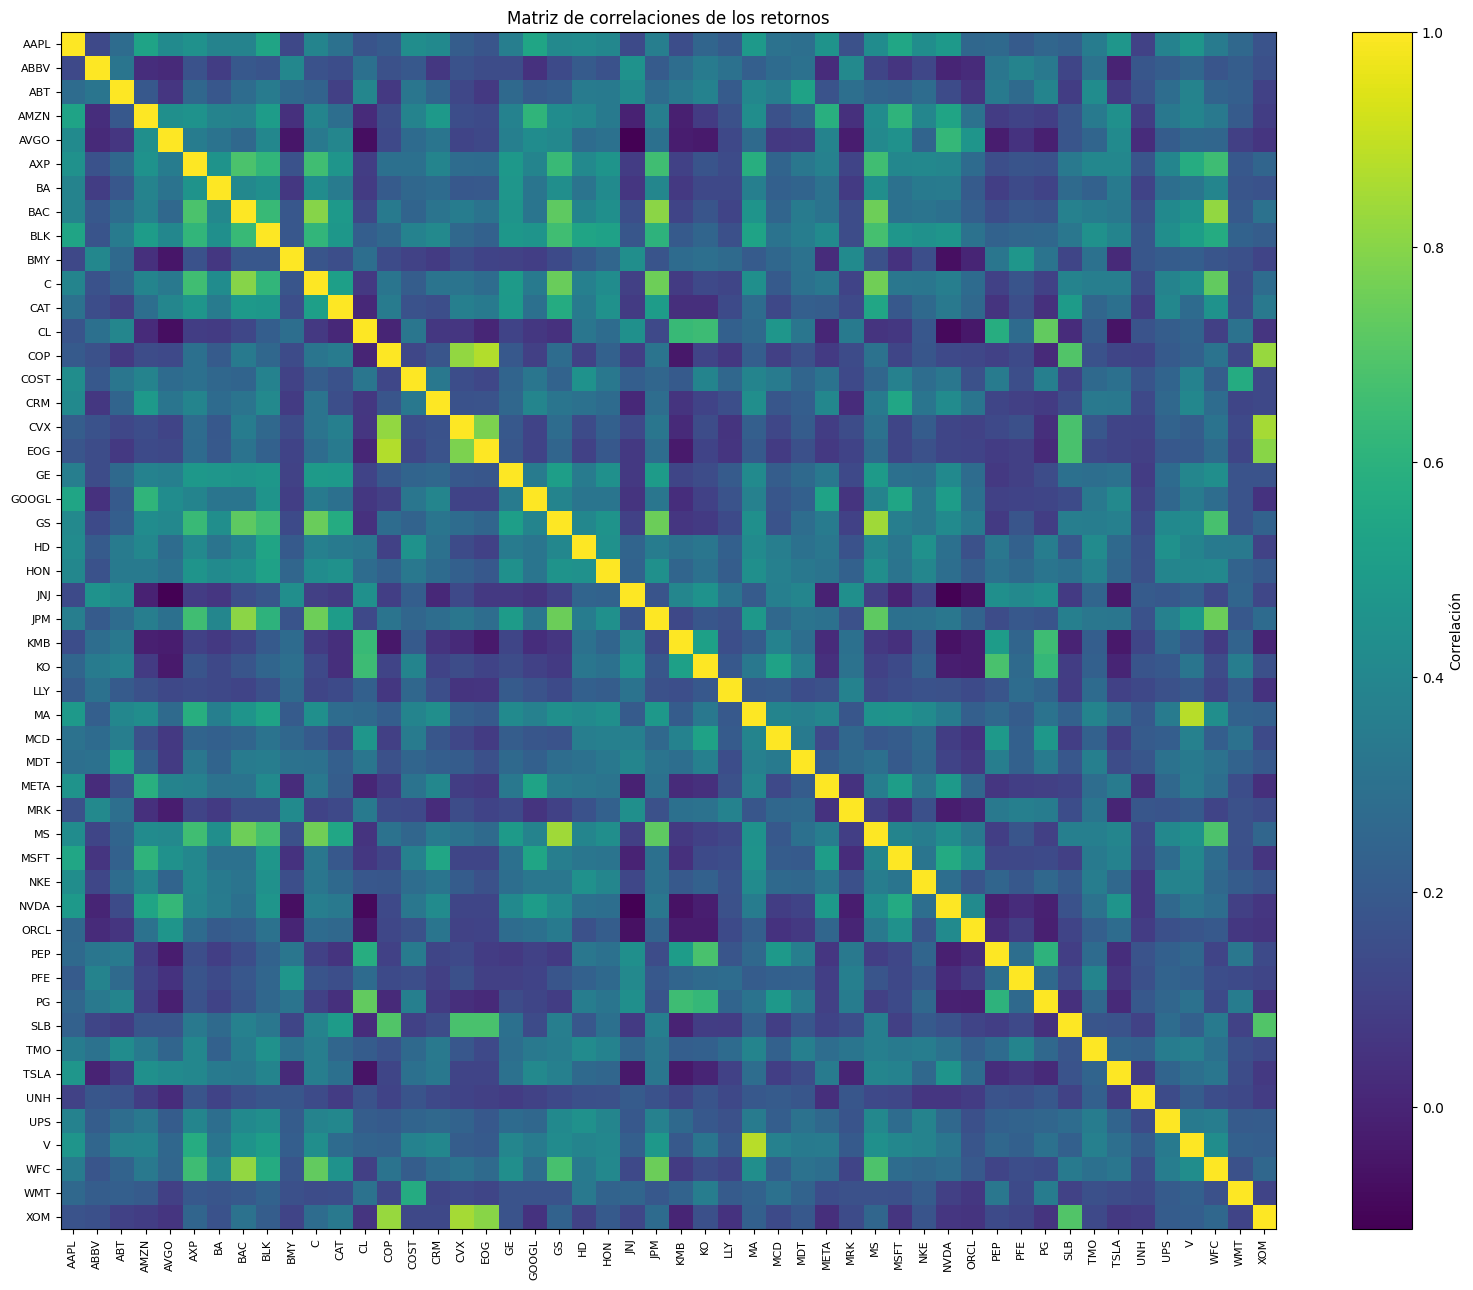

In [88]:
plt.figure(figsize=(16, 13))

plt.imshow(matriz_corr, aspect="auto")
plt.colorbar(label="Correlación")

plt.xticks(
    range(len(matriz_corr.columns)),
    matriz_corr.columns,
    rotation=90,
    fontsize=8
)

plt.yticks(
    range(len(matriz_corr.index)),
    matriz_corr.index,
    fontsize=8
)

plt.title("Matriz de correlaciones de los retornos")
plt.tight_layout()
plt.show()

In [89]:
corr_pares = matriz_corr.where(
    np.triu(np.ones(matriz_corr.shape), k=1).astype(bool)
).stack()

print("5 correlaciones más bajas:")
display(corr_pares.nsmallest(5))

print("5 correlaciones más altas:")
display(corr_pares.nlargest(5))

5 correlaciones más bajas:


Ticker  Ticker
JNJ     NVDA     -0.113495
AVGO    JNJ      -0.111177
CL      NVDA     -0.085384
AVGO    CL       -0.070976
BMY     NVDA     -0.067699
dtype: float64

5 correlaciones más altas:


Ticker  Ticker
MA      V         0.880987
COP     EOG       0.869534
CVX     XOM       0.849990
GS      MS        0.840257
COP     XOM       0.830297
dtype: float64

La matriz de correlaciones muestra que existe una relación positiva entre gran parte de los activos, aunque su intensidad varía. También se observan algunos pares con correlaciones bajas e incluso negativas, como JNJ–NVDA y AVGO–JNJ. Estos activos pueden ser útiles para diversificar el portafolio, ya que sus retornos tienden a presentar movimientos menos similares. Por otro lado, las correlaciones más altas indican activos que presentan comportamientos más parecidos, por lo que combinarlos aporta un menor beneficio de diversificación.

## PCA + Clustering

In [90]:
X = retornos.T

# Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Dimensiones originales:", X.shape)
print("Dimensiones estandarizadas:", X_scaled.shape)

Dimensiones originales: (50, 1248)
Dimensiones estandarizadas: (50, 1248)


In [91]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=retornos.columns
)

pca_df.head()

,PC1,PC2
Ticker,,
AAPL,-8.669548,3.934011
ABBV,14.137001,7.650039
ABT,8.567249,10.247359
AMZN,-20.083023,4.576100
AVGO,-27.232617,-0.645970


In [92]:
varianza = pca.explained_variance_ratio_

print("Varianza explicada PC1:", round(varianza[0], 4))
print("Varianza explicada PC2:", round(varianza[1], 4))
print("Varianza explicada total:", round(varianza.sum(), 4))

Varianza explicada PC1: 0.1616
Varianza explicada PC2: 0.1032
Varianza explicada total: 0.2648


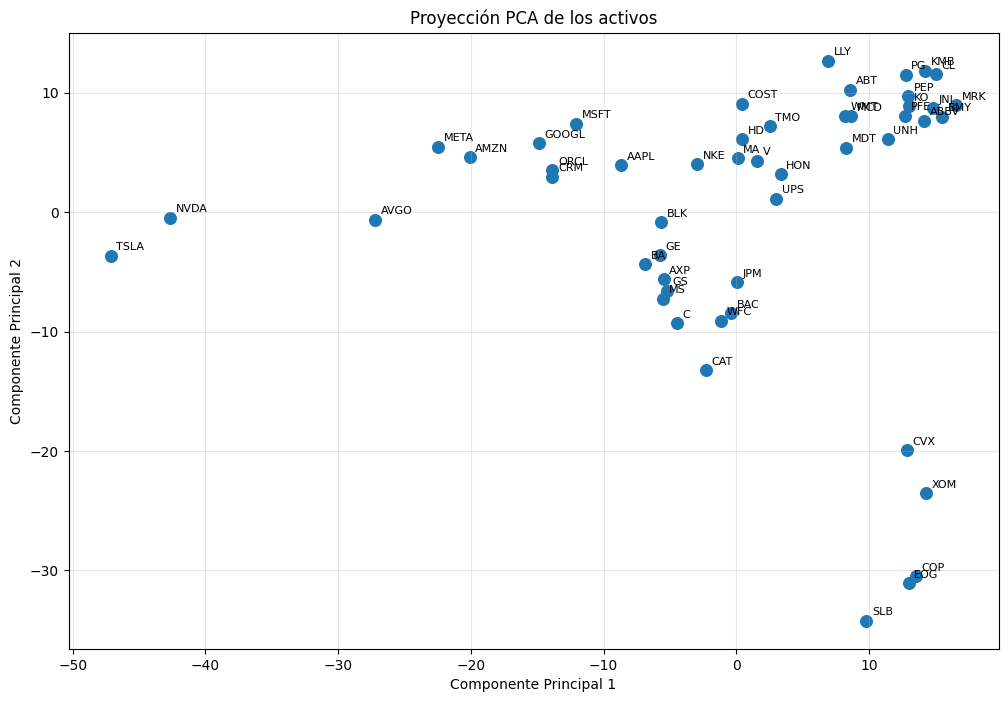

In [93]:
plt.figure(figsize=(12, 8))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    s=70
)

for ticker in pca_df.index:
    plt.annotate(
        ticker,
        (pca_df.loc[ticker, "PC1"],
         pca_df.loc[ticker, "PC2"]),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points"
    )

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Proyección PCA de los activos")
plt.grid(alpha=0.3)
plt.show()

In [94]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

pca_df["KMeans"] = kmeans.fit_predict(X_scaled)

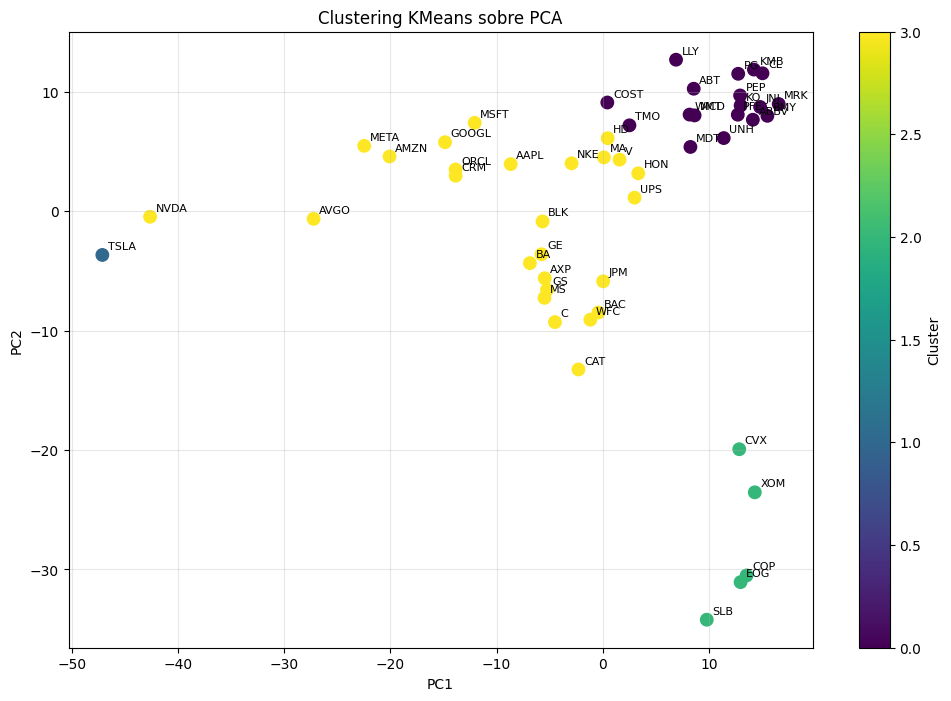

In [95]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["KMeans"],
    s=80
)

for ticker in pca_df.index:
    plt.annotate(
        ticker,
        (pca_df.loc[ticker, "PC1"],
         pca_df.loc[ticker, "PC2"]),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clustering KMeans sobre PCA")
plt.colorbar(scatter, label="Cluster")
plt.grid(alpha=0.3)
plt.show()

In [96]:
for cluster in sorted(pca_df["KMeans"].unique()):
    activos = pca_df[pca_df["KMeans"] == cluster].index.tolist()
    
    print(f"\nCluster {cluster}:")
    print(activos)


Cluster 0:
['ABBV', 'ABT', 'BMY', 'CL', 'COST', 'JNJ', 'KMB', 'KO', 'LLY', 'MCD', 'MDT', 'MRK', 'PEP', 'PFE', 'PG', 'TMO', 'UNH', 'WMT']

Cluster 1:
['TSLA']

Cluster 2:
['COP', 'CVX', 'EOG', 'SLB', 'XOM']

Cluster 3:
['AAPL', 'AMZN', 'AVGO', 'AXP', 'BA', 'BAC', 'BLK', 'C', 'CAT', 'CRM', 'GE', 'GOOGL', 'GS', 'HD', 'HON', 'JPM', 'MA', 'META', 'MS', 'MSFT', 'NKE', 'NVDA', 'ORCL', 'UPS', 'V', 'WFC']


In [97]:
scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(
    pca_df[["PC1", "PC2"]]
)

dbscan = DBSCAN(
    eps=0.7,
    min_samples=3
)

pca_df["DBSCAN"] = dbscan.fit_predict(X_pca_scaled)

pca_df["DBSCAN"].value_counts().sort_index()

DBSCAN
-1     2
 0    43
 1     5
Name: count, dtype: int64

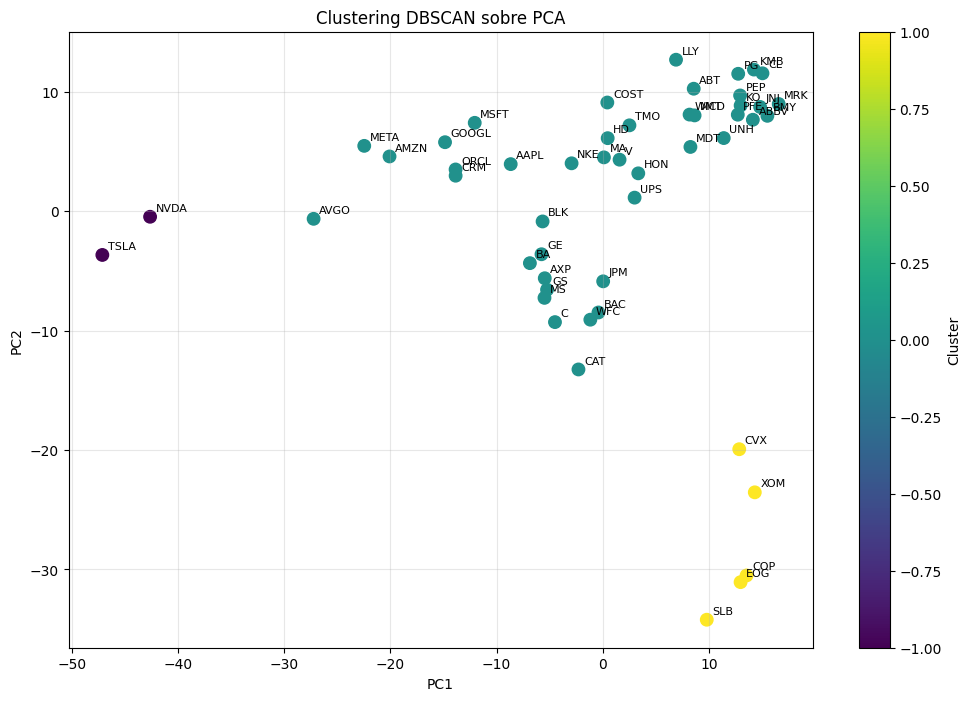

In [98]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["DBSCAN"],
    s=80
)

for ticker in pca_df.index:
    plt.annotate(
        ticker,
        (pca_df.loc[ticker, "PC1"],
         pca_df.loc[ticker, "PC2"]),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clustering DBSCAN sobre PCA")
plt.colorbar(scatter, label="Cluster")
plt.grid(alpha=0.3)
plt.show()

In [99]:
for cluster in sorted(pca_df["DBSCAN"].unique()):

    activos = pca_df[
        pca_df["DBSCAN"] == cluster
    ].index.tolist()

    if cluster == -1:
        print("\nRuido / valores atípicos:")
    else:
        print(f"\nCluster {cluster}:")

    print(activos)


Ruido / valores atípicos:
['NVDA', 'TSLA']

Cluster 0:
['AAPL', 'ABBV', 'ABT', 'AMZN', 'AVGO', 'AXP', 'BA', 'BAC', 'BLK', 'BMY', 'C', 'CAT', 'CL', 'COST', 'CRM', 'GE', 'GOOGL', 'GS', 'HD', 'HON', 'JNJ', 'JPM', 'KMB', 'KO', 'LLY', 'MA', 'MCD', 'MDT', 'META', 'MRK', 'MS', 'MSFT', 'NKE', 'ORCL', 'PEP', 'PFE', 'PG', 'TMO', 'UNH', 'UPS', 'V', 'WFC', 'WMT']

Cluster 1:
['COP', 'CVX', 'EOG', 'SLB', 'XOM']


In [100]:
jerarquico = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

pca_df["Jerarquico"] = jerarquico.fit_predict(X_scaled)

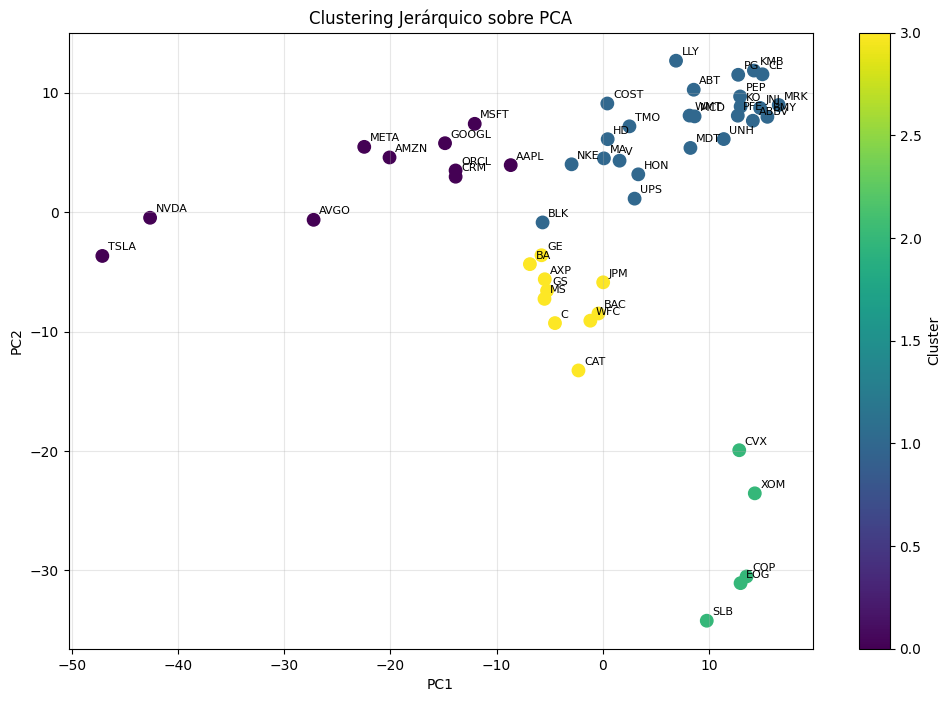

In [101]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Jerarquico"],
    s=80
)

for ticker in pca_df.index:
    plt.annotate(
        ticker,
        (pca_df.loc[ticker, "PC1"],
         pca_df.loc[ticker, "PC2"]),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clustering Jerárquico sobre PCA")
plt.colorbar(scatter, label="Cluster")
plt.grid(alpha=0.3)
plt.show()

In [102]:
for cluster in sorted(pca_df["Jerarquico"].unique()):

    activos = pca_df[
        pca_df["Jerarquico"] == cluster
    ].index.tolist()

    print(f"\nCluster {cluster}:")
    print(activos)


Cluster 0:
['AAPL', 'AMZN', 'AVGO', 'CRM', 'GOOGL', 'META', 'MSFT', 'NVDA', 'ORCL', 'TSLA']

Cluster 1:
['ABBV', 'ABT', 'BLK', 'BMY', 'CL', 'COST', 'HD', 'HON', 'JNJ', 'KMB', 'KO', 'LLY', 'MA', 'MCD', 'MDT', 'MRK', 'NKE', 'PEP', 'PFE', 'PG', 'TMO', 'UNH', 'UPS', 'V', 'WMT']

Cluster 2:
['COP', 'CVX', 'EOG', 'SLB', 'XOM']

Cluster 3:
['AXP', 'BA', 'BAC', 'C', 'CAT', 'GE', 'GS', 'JPM', 'MS', 'WFC']


En los resultados se aprecian principalmente los siguientes perfiles de conglomerados:
Conglomerado defensivo: agrupa principalmente empresas como JNJ, ABBV, PFE, MRK, KO, PEP y PG. En general, presentan betas bajas y menor sensibilidad a los movimientos del mercado. Son activos asociados a sectores como salud y consumo básico, por lo que este grupo podría ser atractivo para inversionistas más conservadores o con mayor aversión al riesgo.
Conglomerado energético: formado claramente por empresas como XOM, CVX, COP, EOG y SLB. Estas acciones presentan un comportamiento similar entre ellas, lo que también se observa en sus altas correlaciones. Por ejemplo, COP–EOG alcanza una correlación de 0,87 y CVX–XOM de 0,85. Este grupo podría ser atractivo para un inversionista que busca exposición al sector energético, pero debe considerar que existe menor diversificación al invertir únicamente dentro de este conglomerado.
Conglomerado intermedio: reúne una mayor variedad de empresas, incluyendo financieras, industriales, tecnológicas y de consumo, como JPM, GS, MS, BAC, AAPL, MSFT, GOOGL y otras. En general, combina activos con beta media y algunos de beta alta, por lo que representa un perfil de riesgo más moderado y diversificado. Podría ser apropiado para inversionistas con tolerancia media al riesgo.
Activos de comportamiento más agresivo: TSLA y NVDA destacan por encontrarse alejados del grupo principal en la representación PCA, y DBSCAN los identifica como observaciones atípicas. Esto es consistente con sus betas elevados: aproximadamente 2,04 para TSLA y 2,17 para NVDA. Estos activos presentan mayor sensibilidad a los movimientos del mercado y serían más adecuados para inversionistas con mayor tolerancia al riesgo y que buscan mayor potencial de rentabilidad aceptando mayor volatilidad.
En conclusión, los conglomerados permiten distinguir perfiles desde defensivos hasta agresivos. Además, PCA y los tres métodos de clustering muestran que las acciones no se diferencian solamente por su sector económico, sino también por la similitud en el comportamiento de sus retornos. Para diversificar, sería conveniente combinar activos de distintos conglomerados, en lugar de concentrar la inversión en empresas que presentan comportamientos muy similares.

A partir de los conglomerados y los niveles de beta, la diversificación puede realizarse seleccionando activos de distintos grupos y ajustando su composición según la aversión al riesgo del inversionista.
Para un inversionista conservador, se priorizarían activos de beta baja y sectores defensivos, como JNJ, KO o PG, incorporando también un activo de otro conglomerado, como XOM, para evitar una concentración excesiva en un solo grupo.
Para un inversionista moderado, se podrían combinar activos defensivos con empresas de beta media, por ejemplo JNJ, XOM y JPM o MSFT. Esto permite incorporar diferentes fuentes de riesgo manteniendo una exposición intermedia a los movimientos del mercado.
Para un inversionista agresivo, se podría aumentar la participación de activos con beta alta, como NVDA o TSLA, combinándolos con activos de otros conglomerados para mantener cierto grado de diversificación.
Por lo tanto, la elección no debería basarse únicamente en seleccionar acciones de baja volatilidad, sino en combinar activos de distintos conglomerados y niveles de beta. A mayor aversión al riesgo, mayor debería ser la participación de activos defensivos y de beta baja; a menor aversión al riesgo, mayor puede ser la exposición a activos de beta alta.

## Optimización de Markowitz

In [103]:
activos_markowitz = ["JNJ", "XOM", "NVDA"]

ret_markowitz = retornos[activos_markowitz]

# Rentabilidad media anualizada
mu = ret_markowitz.mean() * 252

# Matriz de covarianzas anualizada
cov = ret_markowitz.cov() * 252

print("Rentabilidad anual esperada:")
display(mu)

print("Matriz de covarianzas:")
display(cov)

Rentabilidad anual esperada:


Ticker
JNJ     0.114757
XOM     0.271579
NVDA    0.607354
dtype: float64

Matriz de covarianzas:


Ticker,JNJ,XOM,NVDA
Ticker,,,
JNJ,0.030519,0.005754,-0.010313
XOM,0.005754,0.071438,0.008725
NVDA,-0.010313,0.008725,0.270576


In [104]:
def retorno_portafolio(pesos, mu):
    return np.dot(pesos, mu)

def volatilidad_portafolio(pesos, cov):
    return np.sqrt(np.dot(pesos.T, np.dot(cov, pesos)))

In [105]:
rentabilidad_objetivo = 0.10

n = len(activos_markowitz)

pesos_iniciales = np.repeat(1/n, n)

restricciones = (
    {
        "type": "eq",
        "fun": lambda w: np.sum(w) - 1
    },
    {
        "type": "ineq",
        "fun": lambda w: retorno_portafolio(w, mu) - rentabilidad_objetivo
    }
)

# No permitimos ventas cortas
limites = tuple((0, 1) for _ in range(n))

In [106]:
resultado = minimize(
    volatilidad_portafolio,
    pesos_iniciales,
    args=(cov,),
    method="SLSQP",
    bounds=limites,
    constraints=restricciones
)

pesos_optimos = resultado.x

resultado_markowitz = pd.DataFrame({
    "Activo": activos_markowitz,
    "Peso": pesos_optimos
})

resultado_markowitz["Peso_%"] = resultado_markowitz["Peso"] * 100

resultado_markowitz

,Activo,Peso,Peso_%
0,JNJ,0.677040,67.703956
1,XOM,0.227289,22.728880
2,NVDA,0.095672,9.567164


In [107]:
retorno_optimo = retorno_portafolio(pesos_optimos, mu)
volatilidad_optima = volatilidad_portafolio(pesos_optimos, cov)

print(f"Rentabilidad esperada anual: {retorno_optimo:.2%}")
print(f"Volatilidad anual: {volatilidad_optima:.2%}")
print(f"Suma de pesos: {pesos_optimos.sum():.4f}")
print(f"Optimización exitosa: {resultado.success}")

Rentabilidad esperada anual: 19.75%
Volatilidad anual: 14.48%
Suma de pesos: 1.0000
Optimización exitosa: True


La optimización de Markowitz entrega una asignación de 67,70% en JNJ, 22,73% en XOM y 9,57% en NVDA. El portafolio alcanza una rentabilidad esperada anual de 19,75% con una volatilidad anual de 14,48%. La mayor ponderación se concentra en JNJ, activo de beta baja y perfil defensivo, mientras que NVDA, que presenta el mayor beta y volatilidad, recibe una participación menor. XOM permite incorporar exposición a un conglomerado diferente, asociado al sector energético. En conjunto, la optimización permite combinar activos con distintos perfiles de riesgo buscando reducir la volatilidad total del portafolio.

## ARCH, GARCH y GJR-GARCH, VaR 99%

In [108]:
activos_var = ["JNJ", "XOM", "NVDA"]

In [109]:
from arch import arch_model

In [111]:
resultados_modelos = {}

for activo in activos_var:
    
    r = retornos[activo].dropna() * 100

    modelo_arch = arch_model(
        r,
        mean="Constant",
        vol="ARCH",
        p=1,
        dist="normal"
    )
    ajuste_arch = modelo_arch.fit(disp="off")
 
    modelo_garch = arch_model(
        r,
        mean="Constant",
        vol="GARCH",
        p=1,
        q=1,
        dist="normal"
    )
    ajuste_garch = modelo_garch.fit(disp="off")
    
    modelo_gjr = arch_model(
        r,
        mean="Constant",
        vol="GARCH",
        p=1,
        o=1,
        q=1,
        dist="normal"
    )
    ajuste_gjr = modelo_gjr.fit(disp="off")
    
    resultados_modelos[activo] = {
        "ARCH(1)": ajuste_arch,
        "GARCH(1,1)": ajuste_garch,
        "GJR-GARCH(1,1)": ajuste_gjr
    }

In [112]:
comparacion = []

for activo in activos_var:
    for nombre, modelo in resultados_modelos[activo].items():
        
        comparacion.append({
            "Activo": activo,
            "Modelo": nombre,
            "AIC": modelo.aic,
            "BIC": modelo.bic
        })

comparacion_modelos = pd.DataFrame(comparacion)

comparacion_modelos

,Activo,Modelo,AIC,BIC
0,JNJ,ARCH(1),3773.435663,3788.823556
1,JNJ,"GARCH(1,1)",3771.775013,3792.292203
2,JNJ,"GJR-GARCH(1,1)",3773.598936,3799.245424
3,XOM,ARCH(1),4829.002611,4844.390504
4,XOM,"GARCH(1,1)",4757.904030,4778.421221
5,XOM,"GJR-GARCH(1,1)",4759.249282,4784.895770
6,NVDA,ARCH(1),6504.604886,6519.992779
7,NVDA,"GARCH(1,1)",6456.691847,6477.209037
8,NVDA,"GJR-GARCH(1,1)",6433.845283,6459.491771


In [113]:
for activo in activos_var:
    
    tabla = comparacion_modelos[
        comparacion_modelos["Activo"] == activo
    ]
    
    mejor = tabla.loc[tabla["AIC"].idxmin()]
    
    print(
        activo,
        "-> Mejor modelo:",
        mejor["Modelo"],
        "| AIC:",
        round(mejor["AIC"], 2)
    )

JNJ -> Mejor modelo: GARCH(1,1) | AIC: 3771.78
XOM -> Mejor modelo: GARCH(1,1) | AIC: 4757.9
NVDA -> Mejor modelo: GJR-GARCH(1,1) | AIC: 6433.85


Según los criterios AIC y BIC, el modelo GARCH(1,1) presenta el mejor ajuste para JNJ y XOM, mientras que para NVDA el mejor modelo corresponde a GJR-GARCH(1,1). Esto indica que para JNJ y XOM es suficiente modelar la persistencia de la volatilidad mediante un GARCH tradicional. En cambio, en NVDA existe evidencia de un comportamiento asimétrico de la volatilidad, característica que es capturada por el modelo GJR-GARCH.

In [114]:
from scipy.stats import norm

posicion = 10_000_000
confianza = 0.99
z = norm.ppf(confianza)

mejores_modelos = {
    "JNJ": resultados_modelos["JNJ"]["GARCH(1,1)"],
    "XOM": resultados_modelos["XOM"]["GARCH(1,1)"],
    "NVDA": resultados_modelos["NVDA"]["GJR-GARCH(1,1)"]
}

resultados_var = []

for activo, modelo in mejores_modelos.items():

    forecast = modelo.forecast(horizon=1)

    mu_forecast = forecast.mean.iloc[-1, 0]

    varianza_forecast = forecast.variance.iloc[-1, 0]
    sigma_forecast = np.sqrt(varianza_forecast)

    var_pct = (z * sigma_forecast - mu_forecast) / 100

    var_monetario = posicion * var_pct

    resultados_var.append({
        "Activo": activo,
        "Media_Pronosticada_%": mu_forecast,
        "Volatilidad_Pronosticada_%": sigma_forecast,
        "VaR_99_%": var_pct * 100,
        "VaR_99_$": var_monetario
    })

tabla_var = pd.DataFrame(resultados_var)

tabla_var

,Activo,Media_Pronosticada_%,Volatilidad_Pronosticada_%,VaR_99_%,VaR_99_$
0,JNJ,0.035946,1.107108,2.539573,253957.347284
1,XOM,0.082676,1.727972,3.937188,393718.777324
2,NVDA,0.263847,2.804633,6.260706,626070.600915


Los resultados muestran diferencias importantes en el riesgo de los tres activos. Para una posición de $10.000.000, JNJ presenta un VaR diario al 99% de aproximadamente $253.957, XOM de $393.719 y NVDA de $626.071.
Esto significa que, bajo las condiciones estimadas por los modelos, existe aproximadamente un 1% de probabilidad de que la pérdida diaria sea superior a esos montos. JNJ presenta el menor riesgo, mientras que NVDA muestra el mayor VaR, lo que es consistente con los resultados anteriores, donde NVDA presentó un beta alto y un comportamiento más volátil.
En conclusión, los modelos GARCH confirman los perfiles identificados anteriormente, JNJ presenta un comportamiento más defensivo, XOM un riesgo intermedio y NVDA una mayor exposición al riesgo.